# CADETS E3 Results So Far

This notebook uses a real sample exported from the PIDSMaker `cadets_e3.dump` PostgreSQL dataset.

What this notebook demonstrates:

1. Real PIDSMaker -> PostgreSQL -> CSV ingestion
2. Time-windowed provenance graph construction
3. Baseline behavioral anomaly detection
4. GNN training on the CADETS sample slice
5. GNN loss curve and learned threshold
6. Flagged windows and top anomalous edges
7. Current LLM status


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

import json
from datetime import timedelta

import matplotlib.pyplot as plt

from soc_graph.data.dataset import build_datasets
from soc_graph.data.pidsmaker import load_events
from soc_graph.detection.subgraph import build_reduced_subgraph
from soc_graph.model.gnn_inference import load_gnn_detector, score_windows
from soc_graph.model.pipeline import run_baseline_experiment, run_gnn_experiment
from soc_graph.report.llm_report import config_from_env, generate_report
from soc_graph.report.mitre_mapping import map_subgraph
from soc_graph.report.serialize import serialize_reduced_subgraph

CSV_PATH = ROOT / "data" / "processed" / "cadets_e3_sample.csv"
CHECKPOINT_PATH = ROOT / "artifacts" / "models" / "gnn_detector.pt"

assert CSV_PATH.exists(), f"Missing sample export: {CSV_PATH}"


In [2]:
events = load_events(CSV_PATH)
snapshot_ds, artifact_ds = build_datasets(events, window=timedelta(minutes=15))

window_rows = []
for idx, snapshot in enumerate(snapshot_ds.snapshots):
    window_rows.append(
        {
            "window_index": idx,
            "window_start": snapshot.window_start.isoformat(),
            "window_end": snapshot.window_end.isoformat(),
            "nodes": len(snapshot.nodes),
            "agg_edges": len(snapshot.edges),
            "raw_observations": snapshot.total_edge_observations,
        }
    )

print(f"CSV path: {CSV_PATH}")
print(f"Events loaded: {len(events):,}")
print(f"Time windows: {len(snapshot_ds):,}")
print()
for row in window_rows:
    print(
        f"Window {row['window_index']}: "
        f"{row['window_start']} -> {row['window_end']} | "
        f"nodes={row['nodes']}, agg_edges={row['agg_edges']}, raw_obs={row['raw_observations']}"
    )


CSV path: /workspace/data/processed/cadets_e3_sample.csv
Events loaded: 54,317
Time windows: 6

Window 0: 2018-04-02T22:00:00+00:00 -> 2018-04-02T22:15:00+00:00 | nodes=266, agg_edges=1108, raw_obs=6012
Window 1: 2018-04-02T22:15:00+00:00 -> 2018-04-02T22:30:00+00:00 | nodes=299, agg_edges=1711, raw_obs=15957
Window 2: 2018-04-02T22:30:00+00:00 -> 2018-04-02T22:45:00+00:00 | nodes=319, agg_edges=1742, raw_obs=10078
Window 3: 2018-04-02T22:45:00+00:00 -> 2018-04-02T23:00:00+00:00 | nodes=291, agg_edges=1712, raw_obs=10053
Window 4: 2018-04-02T23:00:00+00:00 -> 2018-04-02T23:15:00+00:00 | nodes=318, agg_edges=1821, raw_obs=10390
Window 5: 2018-04-02T23:15:00+00:00 -> 2018-04-02T23:30:00+00:00 | nodes=90, agg_edges=319, raw_obs=1827


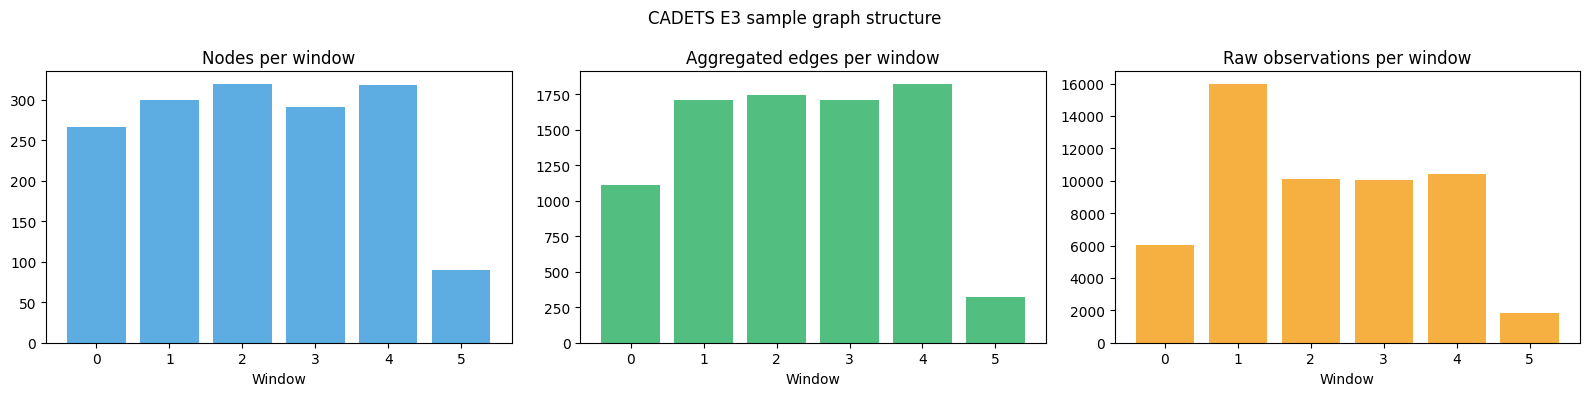

In [3]:
x = [row["window_index"] for row in window_rows]
nodes = [row["nodes"] for row in window_rows]
agg_edges = [row["agg_edges"] for row in window_rows]
raw_obs = [row["raw_observations"] for row in window_rows]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(x, nodes, color="#5DADE2")
axes[0].set_title("Nodes per window")
axes[0].set_xlabel("Window")

axes[1].bar(x, agg_edges, color="#52BE80")
axes[1].set_title("Aggregated edges per window")
axes[1].set_xlabel("Window")

axes[2].bar(x, raw_obs, color="#F5B041")
axes[2].set_title("Raw observations per window")
axes[2].set_xlabel("Window")

fig.suptitle("CADETS E3 sample graph structure")
plt.tight_layout()
plt.show()


## Baseline detector

In [4]:
baseline_result = run_baseline_experiment(
    snapshot_ds,
    artifact_ds,
    benign_ratio=0.7,
    threshold_k=3.0,
)

baseline_counts = [len(flagged) for flagged in baseline_result.flagged_windows]

print("Baseline training summary")
print(json.dumps(
    {
        "num_windows": baseline_result.training_summary.num_windows,
        "mean_edges_per_window": baseline_result.training_summary.mean_edges_per_window,
        "learned_threshold": baseline_result.training_summary.learned_threshold,
        "benign_score_count": baseline_result.training_summary.benign_score_count,
    },
    indent=2,
))
print()
print("Flagged edge counts per test window:", baseline_counts)


Baseline training summary
{
  "num_windows": 4,
  "mean_edges_per_window": 1568.25,
  "learned_threshold": 4.7332950359649795,
  "benign_score_count": 6273
}

Flagged edge counts per test window: [1139, 201]


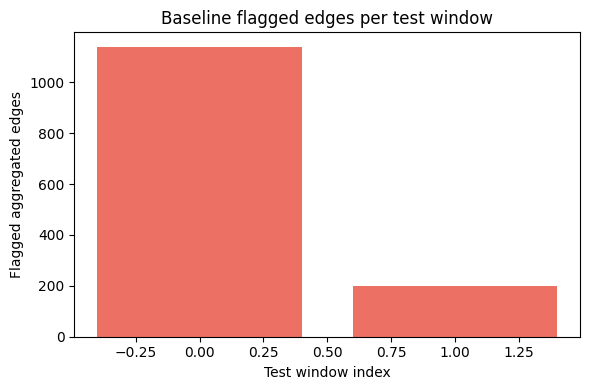

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(range(len(baseline_counts)), baseline_counts, color="#EC7063")
plt.title("Baseline flagged edges per test window")
plt.xlabel("Test window index")
plt.ylabel("Flagged aggregated edges")
plt.tight_layout()
plt.show()


## GNN detector

In [6]:
gnn_result = run_gnn_experiment(
    snapshot_ds,
    artifact_ds,
    benign_ratio=0.7,
    epochs=5,
    threshold_k=3.0,
    checkpoint_path=str(CHECKPOINT_PATH),
)

gnn_counts = [len(flagged) for flagged in gnn_result.flagged_windows]

print("GNN training summary")
print(json.dumps(
    {
        "epochs": gnn_result.epochs,
        "final_loss": gnn_result.final_loss,
        "loss_history": gnn_result.loss_history,
        "learned_threshold": gnn_result.learned_threshold,
        "checkpoint_path": gnn_result.checkpoint_path,
    },
    indent=2,
))
print()
print("Flagged edge counts per test window:", gnn_counts)


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GNN training summary
{
  "epochs": 5,
  "final_loss": 2.7222399711608887,
  "loss_history": [
    10.982454419136047,
    6.718893885612488,
    5.0076682567596436,
    3.912711799144745,
    2.839871346950531
  ],
  "learned_threshold": 5.023370055361954,
  "checkpoint_path": "/workspace/artifacts/models/gnn_detector.pt"
}

Flagged edge counts per test window: [210, 0]


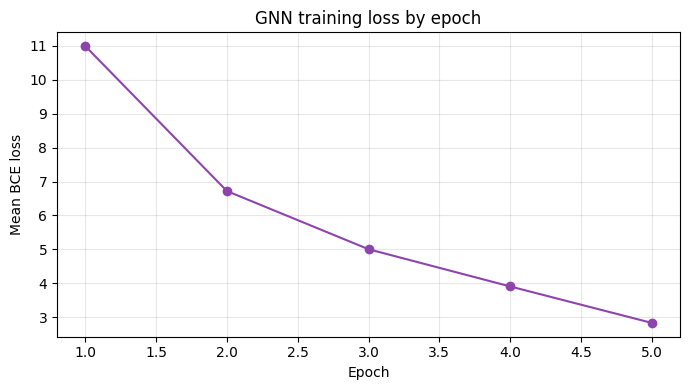

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(gnn_result.loss_history) + 1), gnn_result.loss_history, marker="o", color="#8E44AD")
plt.title("GNN training loss by epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean BCE loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


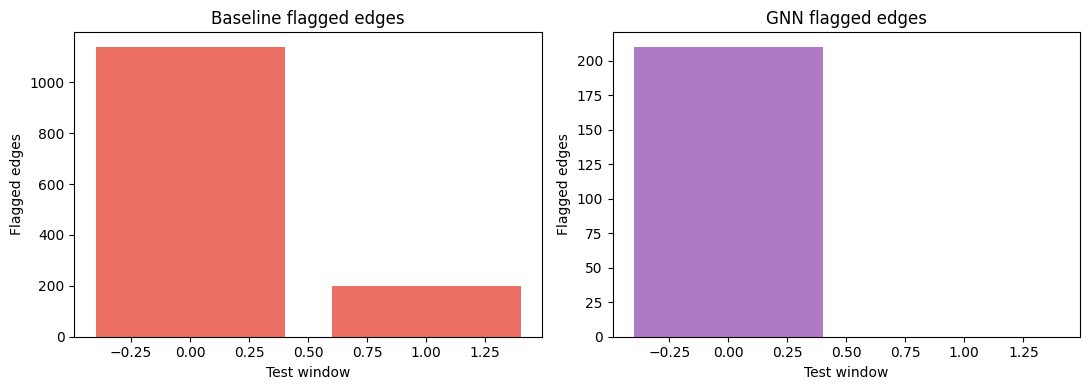

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(len(baseline_counts)), baseline_counts, color="#EC7063")
axes[0].set_title("Baseline flagged edges")
axes[0].set_xlabel("Test window")
axes[0].set_ylabel("Flagged edges")

axes[1].bar(range(len(gnn_counts)), gnn_counts, color="#AF7AC5")
axes[1].set_title("GNN flagged edges")
axes[1].set_xlabel("Test window")
axes[1].set_ylabel("Flagged edges")

plt.tight_layout()
plt.show()


## Top anomalous edges from the GNN

In [9]:
detector = load_gnn_detector(CHECKPOINT_PATH)
_, test_artifacts = artifact_ds.train_test_split(benign_ratio=0.7)
gnn_scores = score_windows(detector, test_artifacts)

top_edges = []
for window_idx, window_scores in enumerate(gnn_scores):
    for edge_key, score in window_scores.items():
        top_edges.append((score, window_idx, edge_key))

top_edges = sorted(top_edges, reverse=True)[:20]
for rank, (score, window_idx, edge_key) in enumerate(top_edges, start=1):
    print(f"{rank:02d}. window={window_idx}  score={score:.4f}  edge={edge_key}")


01. window=0  score=7.1154  edge=982474ba27316b44a877515fb93080cd3db85e0a886a48a6c56fdbdefb87c132:379485:READ:4a6e3849a809c5397783c20dfc31520ab9a5bee154345968ca4b301db3580be7:155983
02. window=0  score=7.1153  edge=30da516b5b9bfc1a17cd6db6af59c8ae9bd947db37b0893d65efadf00a356999:379490:READ:4a6e3849a809c5397783c20dfc31520ab9a5bee154345968ca4b301db3580be7:155983
03. window=0  score=7.1141  edge=982474ba27316b44a877515fb93080cd3db85e0a886a48a6c56fdbdefb87c132:379485:READ:c9bc833d6d47f5513a7600c787746dd3267747acdfedffb82d1789b29ebe9f75:155993
04. window=0  score=7.1140  edge=30da516b5b9bfc1a17cd6db6af59c8ae9bd947db37b0893d65efadf00a356999:379490:READ:c9bc833d6d47f5513a7600c787746dd3267747acdfedffb82d1789b29ebe9f75:155993
05. window=0  score=7.1139  edge=a175028def6fe382386dec6c97136c2d9f4725ea408424a1aeac0484e4938460:379491:READ:4a6e3849a809c5397783c20dfc31520ab9a5bee154345968ca4b301db3580be7:155983
06. window=0  score=7.1138  edge=4e79ca8e9a1c6da1981936400a26258dd00d29302bc7395910ce0c48e

In [10]:
alerts = []
for idx, (snapshot, flagged) in enumerate(zip(gnn_result.test_snapshots, gnn_result.flagged_windows, strict=True)):
    if not flagged:
        continue
    alert_id = f"cadets-sample-gnn-alert-{idx + 1:03d}"
    reduced = build_reduced_subgraph(snapshot=snapshot, flagged_scores=flagged, alert_id=alert_id)
    alerts.append(serialize_reduced_subgraph(reduced))

print(f"GNN produced {len(alerts)} serialized alert(s).")
if alerts:
    first_alert = alerts[0]
    print(json.dumps(
        {
            "alert_id": first_alert["alert_id"],
            "flagged_edge_count": first_alert["flagged_edge_count"],
            "total_edge_count": first_alert["total_edge_count"],
            "component_count": first_alert["component_count"],
            "num_nodes": len(first_alert["nodes"]),
            "num_edges": len(first_alert["edges"]),
        },
        indent=2,
    ))


GNN produced 1 serialized alert(s).
{
  "alert_id": "cadets-sample-gnn-alert-001",
  "flagged_edge_count": 210,
  "total_edge_count": 1821,
  "component_count": 1,
  "num_nodes": 55,
  "num_edges": 210
}


## MITRE and report layer

In [11]:
if alerts:
    edge_hints = [
        {
            "src_type": edge["src_type"],
            "edge_type": edge["type"],
            "dst_type": edge["dst_type"],
        }
        for edge in alerts[0]["edges"]
    ]
    mitre = map_subgraph(edge_hints)
    print("Mapped ATT&CK techniques:")
    for item in mitre[:10]:
        print(f"- {item['technique_id']} {item['technique_name']} [{item['tactic']}]")
else:
    print("No alerts available for ATT&CK mapping.")


Mapped ATT&CK techniques:
- T1105 Ingress Tool Transfer [Command and Control]
- T1071 Application Layer Protocol [Command and Control]
- T1074 Data Staged [Collection]
- T1027 Obfuscated Files or Information [Defense Evasion]
- T1547 Boot or Logon Autostart Execution [Persistence]
- T1571 Non-Standard Port [Command and Control]
- T1021 Remote Services [Lateral Movement]
- T1048 Exfiltration Over Alternative Protocol [Exfiltration]
- T1041 Exfiltration Over C2 Channel [Exfiltration]
- T1059 Command and Scripting Interpreter [Execution]


In [12]:
llm_cfg = config_from_env()
print("LLM configured:" , bool(llm_cfg))
if llm_cfg:
    llm_cfg.timeout = max(llm_cfg.timeout, 600)
    print(f"Provider: {llm_cfg.provider}")
    print(f"Model: {llm_cfg.model}")
else:
    print("No live LLM is configured in this environment.")
    print("The report layer currently falls back to a deterministic placeholder.")

if alerts:
    report = generate_report(alerts[0], config=llm_cfg)
    print()
    print("Report verdict:", report.verdict)
    print("Confidence:", report.confidence)
    print("Narrative:", report.narrative)
    print("Note:", report.note)


LLM configured: True
Provider: ollama
Model: qwen2.5:7b



Report verdict: suspicious
Confidence: medium
Narrative: The graph depicts a complex interaction involving network communication, file operations, and process execution. The timeline suggests the following sequence of events:

1. A process with the hash `fb79fcba9fd49f2611d64e017df9ba4b4a5353037639663de0f4e2884711864c` and PID 155 received data from an external source via a socket at `2018-04-02T23:13:26+00:00`.
2. This process then wrote data to the file `/tmp/file123` with the hash `f7e90b9c5a5d9045e380d2d64030e95b0eb8e673` at `2018-04-02T23:13:30+00:00`.
3. A process with the hash `f7b0e537639663de0f4e2884711864c` and PID 155 then spawned a child process at `2018-04-02T23:13:30+00:00`.
4. The main process received additional data from the network, possibly from the same source as in step 1.
5. At `2018-04-02T23:13:42+00:00`, a process with PID 169 sent data over port 1337 to an unspecified external IP address, indicating exfiltration or command and control communication.
Note: 


## Interpretation

What we can concretely do so far:

- ingest real PIDSMaker CADETS E3 data through PostgreSQL export
- build time-windowed provenance graphs
- run a baseline structural anomaly detector
- run the first GNN path on a real CADETS-derived sample slice
- serialize suspicious subgraphs and map them to MITRE ATT&CK hints
- generate an analyst report through Ollama when configured, otherwise fall back to a deterministic placeholder

What is not set up yet:

- no full-dataset CADETS E3 run over all 36M+ events yet
- no polished evaluation benchmark yet
